<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/labs/cs473_lab_week_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 473 Lab Week 9

## Introduction:

You will turn in an iPython notebook that performs Gaussian process regression on a simple dataset. You will explore multiple kernels and vary their parameter settings.

When you are done, you should produce visualizations like the following (for noiseless observations):

![noiseless figure](https://raw.githubusercontent.com/wingated/cs473/main/labs/images/lab_week_9_image1.png)

and like this (for noisy observations):

![noisy figure](https://raw.githubusercontent.com/wingated/cs473/main/labs/images/lab_week_9_image2.png)


---
## Grading standards   

Your notebook will be graded on the following:

* 20% Correct implementation of three kernels
* 30% Correct implementation of noiseless GPR
* 30% Correct implementation of noisy GPR
* 20% Six tidy and legible plots, with appropriate ranges

---
## Description

The data that we will use for this lab is simple:

```python
data_xvals = numpy.atleast_2d( [ 1.0, 3.0, 5.0, 6.0, 7.0, 8.0 ] )
data_yvals = numpy.sin( data_xvals )
```
You must perform Gaussian process regression on this dataset, and produce visualizations for both noiseless and noisy observations.

The key equations are given in 17.28 - 17.30 (for the noiseless case) and 17.34-17.36 (for the noisy case).

Your notebook should produce one visualization for each of the following kernel types:

* The linear kernel
* The Gaussian (or RBF) kernel (Eqn. 17.3)
* The polynomial kernel (in the text right after Eqn. 17.20)

Therefore, your notebook should produce six different visualizations: two for each kernel type.

For the noisy observation case, use \sigma_n^2=0.1.

For the polynomial kernel use a degree of 3.

For the Gaussian / RBF kernel, set all parameters to 1.0

The mean function for this lab should always return 0.

You should also answer the following questions:

* What happens when the bandwidth parameter \sigma_n of the Gaussian kernel gets small? Gets large?
* What happens when the degree M of the polynomial kernel gets small? Gets large?

Your visualizations should be done on the range [-2 10] of the x-axis.

For the errorbars, you can just plot the mean +/- the variance. This isn't really a statistically meaningful quantity, but it makes the plots look nice. :)

*Hint: a Gaussian process only allows you to make a prediction for a single query point. So how do you generate the smoothly varying lines in the example images?*


In [2]:
import numpy as np
data_xvals = np.atleast_2d( [ 1.0, 3.0, 5.0, 6.0, 7.0, 8.0 ] )
data_yvals = np.sin( data_xvals )

In [3]:
print(f'x data: {data_xvals}')
print(f'y data: {data_yvals}')

x data: [[1. 3. 5. 6. 7. 8.]]
y data: [[ 0.84147098  0.14112001 -0.95892427 -0.2794155   0.6569866   0.98935825]]


Code 3 kernel functions (gaussian, linmear polynomial)

In [4]:
def RBF(x1,x2): # setting all parameters to 1
# '''input Nx1 x1
#          Mx1 x2'''
  l = 1
  sq_dist = (x1-x2.T)**2

  return np.exp(sq_dist/(-2*l**2))

In [5]:
def linkern(x1, x2, c=0):
#input column vectors of row vectors == matrices.
#output matrix of scalars
  return(
      (x1@x2.T) + c
  )

In [6]:
def polykern(x1, x2, c=0, M=3):
  return(
      ((x1@x2.T) + c)**M
  )


Code the 4 covariance matrices


In [7]:
def K_XX(X, kernel):
  return (
      kernel(X,X)
  )
def K_X_star(X, X_star, kernel):
  return (
      kernel(X,X_star)
  )
def K_star_X(X, X_star, kernel):
  return (
      kernel(X_star, X)
  )
def K_star_star(X_star, kernel):
  return (
      kernel(X_star,X_star)
  )

In [9]:
# means! These return vectors
def MU_X(X):
   return (
       0
   )
def MU_star(X_star):
  return (
      0
  )

Code for conditioning multivariate gaussian, returning mean and sigma

In [12]:
# here we are going to use our gaussian conditioning formulae

def cond_mu(mu_X, y_train, mu_star, K_X_X, K_star_X):

  K_X_X_inv = np.linalg.pinv(K_X_X)
  mu_star_star_cond_X = mu_star + K_star_X@K_X_X_inv@(y_train - mu_X)

  return mu_star_star_cond_X

In [13]:
def cond_cov_mat(K_star_star, K_star_X, K_X_X, K_X_star):
  K_X_X_inv = np.linalg.pinv(K_X_X)
  K_star_star_cond_X = K_star_star - K_star_X@K_X_X_inv@K_X_star
  return K_star_star_cond_X


Actual calculations for linear kernel

In [19]:
#train data
X_train = data_xvals.T
y_train = data_yvals.T #f(x)
mu_X = np.zeros_like(X_train)

#test data
X_test = np.arange(-2,10.1,0.1).reshape(-1,1)
mu_star = np.zeros_like(X_test)

# linear kernel sigmas
lin_K_xx = K_XX(X_train, linkern)
lin_K_xstar = K_X_star(X_train, X_test, linkern)
lin_K_starx = K_star_X(X_train, X_test, linkern)
lin_K_starstar = K_star_star(X_test, linkern)

#RBF kernel sigmas
rbf_K_xx = K_XX(X_train, RBF)
rbf_K_xstar = K_X_star(X_train, X_test, RBF)
rbf_K_starx = K_star_X(X_train, X_test, RBF)
rbf_K_starstar = K_star_star(X_test, RBF)

#polynomial kernel sigmas
ply_K_xx = K_XX(X_train, polykern)
ply_K_xstar = K_X_star(X_train, X_test, polykern)
ply_K_starx = K_star_X(X_train, X_test, polykern)
ply_K_starstar = K_star_star(X_test, polykern)


Conditioning gram matrix on training data

In [20]:
#linear kernel
lin_K_star_star_cond_X = cond_cov_mat(lin_K_starstar, lin_K_starx, lin_K_xx, lin_K_xstar)
lin_mu_star_star_cond_X = cond_mu(mu_X, y_train, mu_star, lin_K_xx, lin_K_starx)

# gaussian kernel
rbf_K_star_star_cond_X = cond_cov_mat(rbf_K_starstar, rbf_K_starx, rbf_K_xx, rbf_K_xstar)
rbf_mu_star_star_cond_X = cond_mu(mu_X, y_train, mu_star, rbf_K_xx, rbf_K_starx)

#polynomial kernel
ply_K_star_star_cond_X = cond_cov_mat(ply_K_starstar, ply_K_starx, ply_K_xx, ply_K_xstar)
ply_mu_star_star_cond_X = cond_mu(mu_X, y_train, mu_star, ply_K_xx, ply_K_starx)



Now we're going to refactor the code to allow noisy observations


In [21]:
# variance
sigma_n_sq = 0.1

# Identity matrices for trainign and testing shapes
I_train = np.eye(len(X_train))
I_test = np.eye(len(X_test))

# Add the noise
noisy_lin_K_xx = lin_K_xx + (sigma_n_sq * I_train)
noisy_lin_K_starstar = lin_K_starstar + (sigma_n_sq * I_test)

noisy_lin_cov = cond_cov_mat(noisy_lin_K_starstar, lin_K_starx, noisy_lin_K_xx, lin_K_xstar)
noisy_lin_mu = cond_mu(mu_X, y_train, mu_star, noisy_lin_K_xx, lin_K_starx)

Now let's try to plot the noisless type - linear first


In [23]:
import matplotlib.pyplot as plt

In [28]:
#first we need to get the x's
x_plot = X_test.flatten()

#now the y's (avg mus after conditioning)
mu_plot = lin_mu_star_star_cond_X.flatten()

#now the variance for the uncertainty. get rid of covariances, just want diagonals
y_variance = np.diag(np.abs(lin_K_star_star_cond_X))
std_plot = np.sqrt(y_variance)

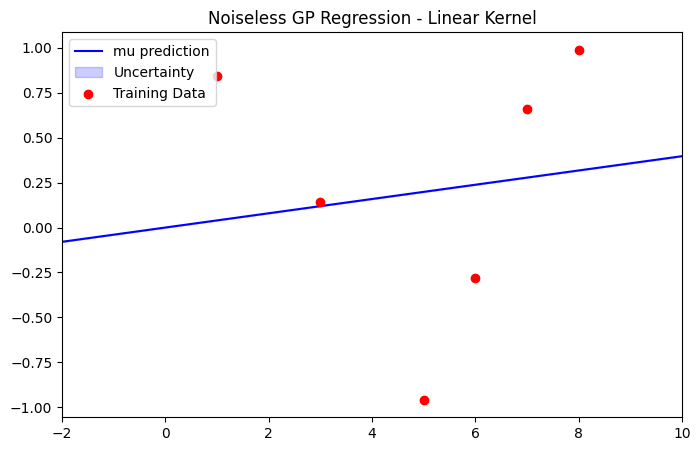

In [30]:
plt.figure(figsize=(8,5))
plt.plot(x_plot, mu_plot, 'b-', label="mu prediction")
plt.gca().fill_between(
    x_plot, mu_plot - std_plot, mu_plot + std_plot,
    color='blue', alpha=0.2, label='Uncertainty'
)
# Scatter the original training anchors on top
plt.scatter(X_train.flatten(), y_train.flatten(), color='red', zorder=5, label='Training Data')

# Clean up the graph limits
plt.xlim([-2, 10])
plt.title("Noiseless GP Regression - Linear Kernel")
plt.legend()
plt.show()


Alright we'll make the master plot now


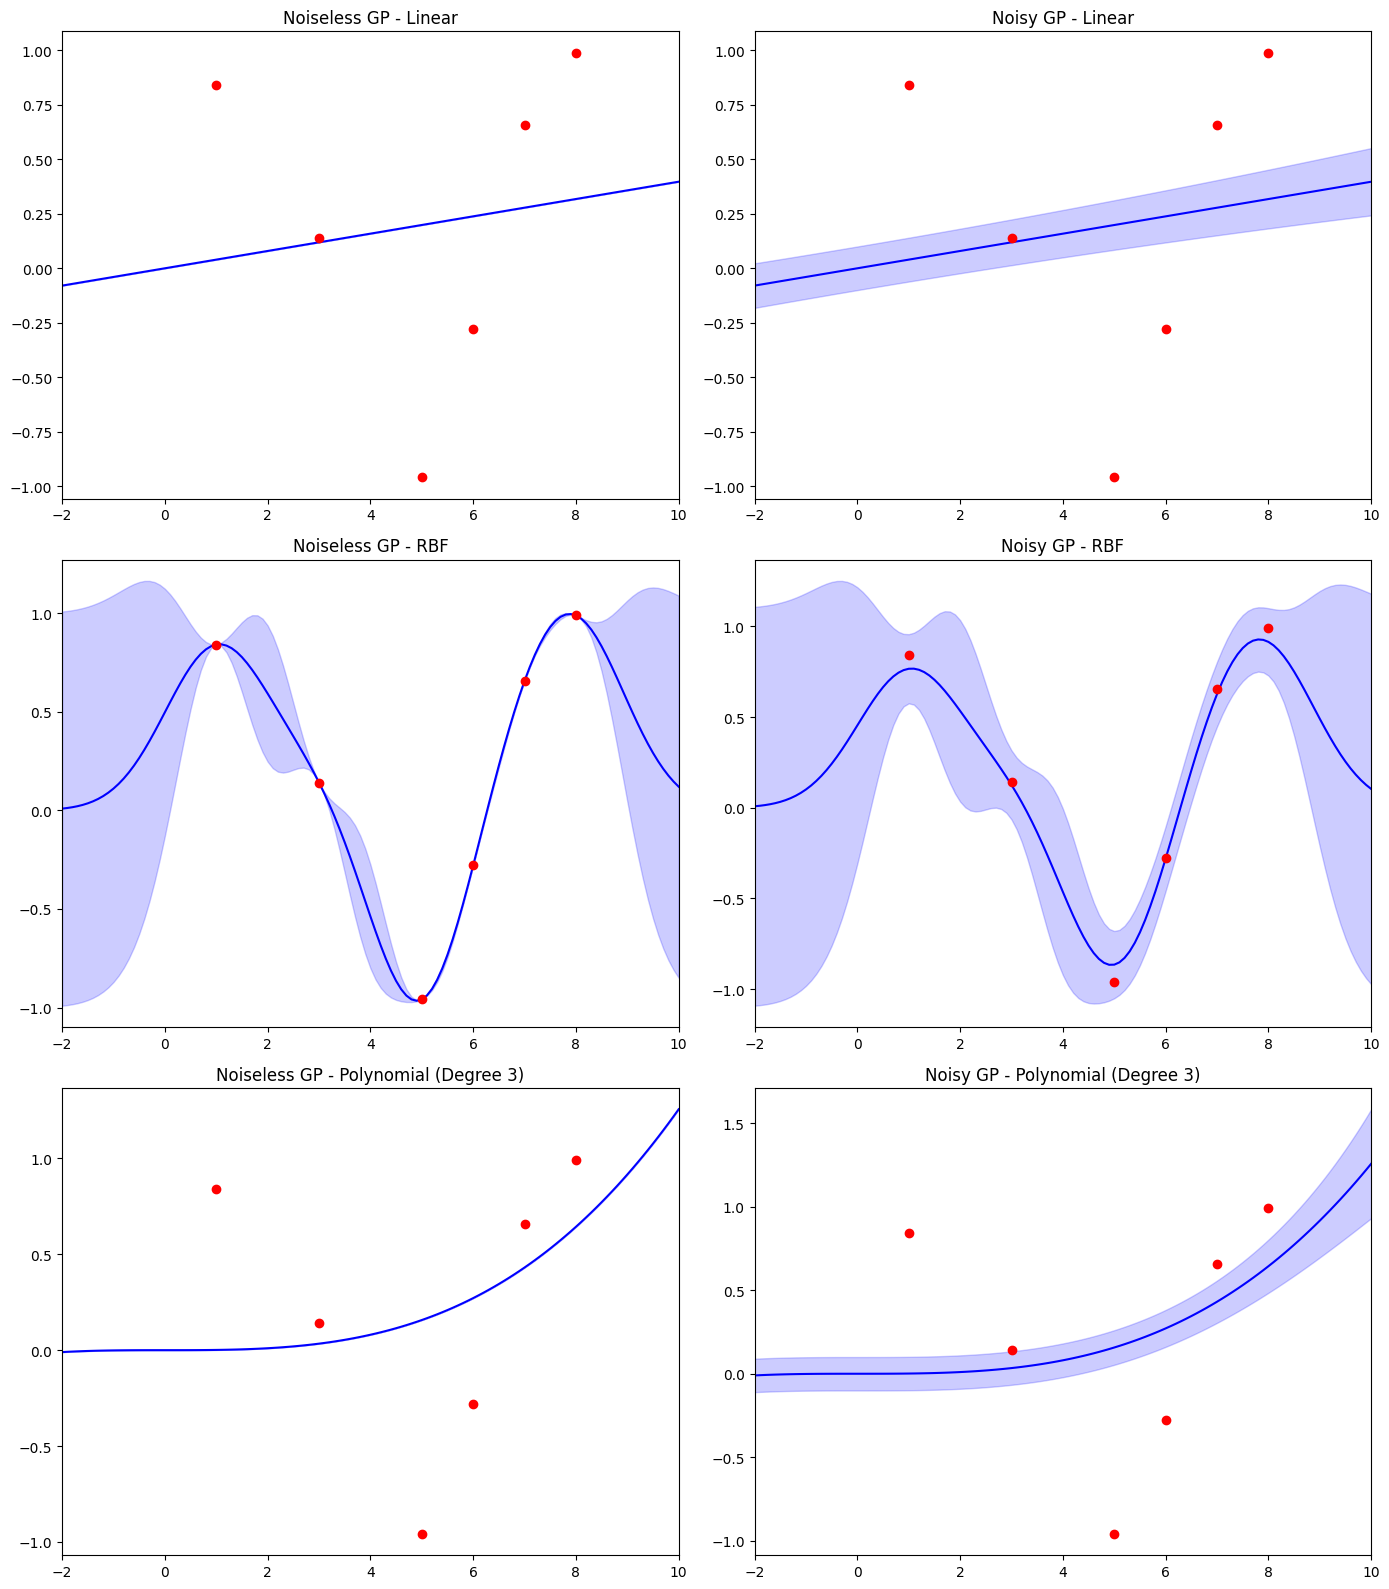

In [33]:
# set up the data again to be safe
X_train = data_xvals.T
y_train = data_yvals.T
mu_X = np.zeros_like(X_train)

X_test = np.arange(-2, 10.1, 0.1).reshape(-1, 1)
mu_star = np.zeros_like(X_test)

sigma_n_sq = 0.1 # Noise variance for the right column

# Plotting Helper Function
def plot_gp(ax, kernel_func, kernel_title, noise_var=0.0):
    # Build base matrices
    K_xx = K_XX(X_train, kernel_func)
    K_xstar = K_X_star(X_train, X_test, kernel_func)
    K_starx = K_star_X(X_train, X_test, kernel_func)
    K_starstar = K_star_star(X_test, kernel_func)

    # Add noise to diagonals if we are doing the noisy version
    if noise_var > 0:
        K_xx += noise_var * np.eye(len(X_train))
        K_starstar += noise_var * np.eye(len(X_test))

    # Run your exact conditioning functions!
    cov = cond_cov_mat(K_starstar, K_starx, K_xx, K_xstar)
    mu = cond_mu(mu_X, y_train, mu_star, K_xx, K_starx)

    # Extract standard deviation
    var = np.diag(np.abs(cov))

    # Flatten everything for matplotlib
    x_flat, mu_flat = X_test.flatten(), mu.flatten()

    # Draw!
    ax.plot(x_flat, mu_flat, 'b-', label='Mean')
    ax.fill_between(x_flat, mu_flat - var, mu_flat + var, color='blue', alpha=0.2)
    ax.scatter(X_train.flatten(), y_train.flatten(), color='red', zorder=5, label='Data')

    ax.set_xlim([-2, 10])
    prefix = "Noisy" if noise_var > 0 else "Noiseless"
    ax.set_title(f"{prefix} GP - {kernel_title}")

# Build the 3x2 Grid
# Creates a massive figure with 3 rows and 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 16))

# Row 0: Linear Kernel (Left: Noiseless, Right: Noisy)
plot_gp(axes[0, 0], linkern, "Linear")
plot_gp(axes[0, 1], linkern, "Linear", noise_var=sigma_n_sq)

# Row 1: RBF Kernel (Left: Noiseless, Right: Noisy)
plot_gp(axes[1, 0], RBF, "RBF")
plot_gp(axes[1, 1], RBF, "RBF", noise_var=sigma_n_sq)

# Row 2: Polynomial Kernel (Left: Noiseless, Right: Noisy)
plot_gp(axes[2, 0], polykern, "Polynomial (Degree 3)")
plot_gp(axes[2, 1], polykern, "Polynomial (Degree 3)", noise_var=sigma_n_sq)

# Clean up layout and display
plt.tight_layout()
plt.show()

What happens when the bandwidth parameter \sigma_n of the Gaussian kernel gets small? Gets large?
What happens when the degree M of the polynomial kernel gets small? Gets large?


The bandwidth**2 in RBF is what divides the squared distance before exponentiation. This mean that a high bandwidth will make points more similar than a low bandwidth will. When l is large, the exponent becomes less-negative so similarities go up. When l is small, the exponent becomes more-negative so similarities go down.

M controls how complex the feature space will be. Since we are dotting the vectors in feature space, if we use a polynomial in the feature space then we can hit more points by overfitting. M grows large --> overfitting, M small --> underfitting.
Again, this is because the FEATURE SPACE has access to high degrees of freedom.

---
## Hints

The following functions may be useful to you:

In [ ]:
numpy.arange()

plt.gca().fill_between
plt.scatter

numpy.linalg.pinv

numpy.eye